In [19]:
from datasets import load_from_disk
import matplotlib.pyplot as plt
import numpy as np

In [20]:
import json 

In [21]:
og_ds = load_from_disk("../RAG/all-texts-metadata_topics")

In [22]:
with open("../RAG/params.json", 'r') as f:
    params = json.load(f)

In [24]:
if params["bwiki"] == "True":
    print(f"    Filtering out wiki")
    filtered_ds = og_ds.filter(lambda example: example["Source"] != "wiki")

if params["topics"] is not None:
    print(f"    Filtering out topics")
    filtered_ds = filtered_ds.filter(lambda example: example['Topic'] in params["topics"])

    Filtering out topics


Filter:   0%|          | 0/2257711 [00:00<?, ? examples/s]

In [26]:
(len(filtered_ds)/len(og_ds))*100

0.40781893441258854

In [30]:
def plot_barchart(ds):
    counts = ds.to_pandas().groupby(["Source", "SourceLang"]).size().reset_index(name="count")
    # print(counts.groupby(['Source', 'SourceLang'])['count'].agg('sum'))
    df = ds.to_pandas()
    df["Source"] = ["blbooks" if x == "blboooks" else x for x in df["Source"]]
    counts = df.groupby(["Source", "SourceLang"]).size().reset_index(name="count")
    a = counts.groupby('Source')['count'].transform('sum')
    # print(counts.groupby(['Source', 'SourceLang'])['count'].agg('sum'))
    counts['norm_count'] = counts['count'].div(a)
    
    pivot = counts.pivot(index="Source", columns="SourceLang", values="norm_count").fillna(0)
    pivot.plot(kind="bar", figsize=(8, 6))
    
    plt.title("Language distribution by text source (normalized)")
    plt.xlabel("Text source")
    plt.ylabel("Norm count")
    plt.xticks(rotation=45)
    plt.legend(title="Language")
    plt.tight_layout()
    plt.show()

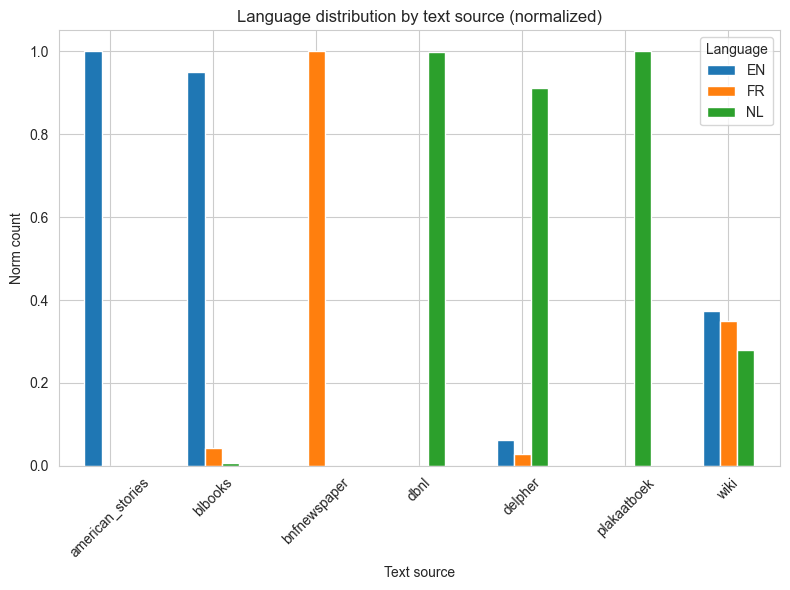

In [31]:
plot_barchart(og_ds)

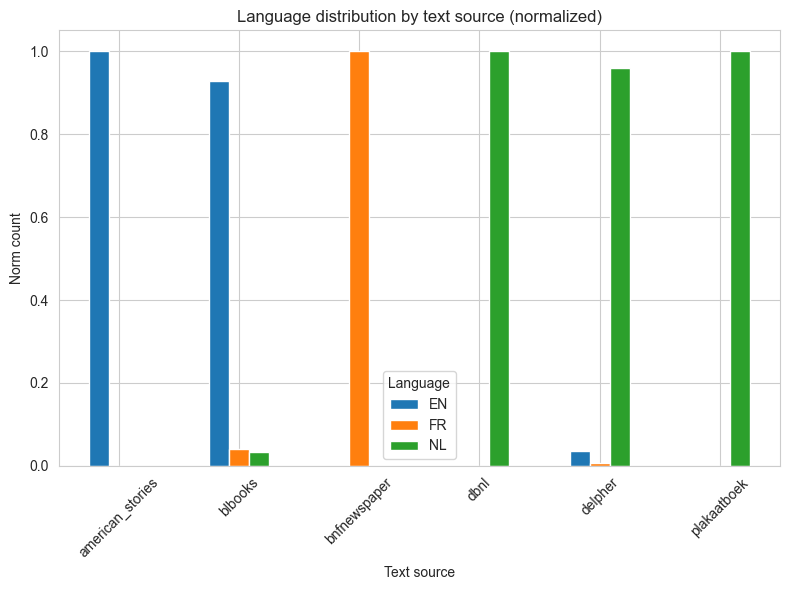

In [33]:
plot_barchart(filtered_ds)